In [30]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [31]:
df = pd.read_csv("C:/Users/nived/New folder (2)/AI-Business-Operations-Management-Platform/datasets/raw/final_project_module.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (8016, 32)


,task_id,project_id,employee_id,task_title,task_description,task_priority,task_status,task_start_date,task_deadline,required_skill,...,email,department,job_role,experience_years,hire_date,skills,availability_status,workload_percentage,active_tasks,performance_score
0,T001,P00041,EMP008,UI Design,UI Design for the Inventory Management System ...,Medium,In Progress,2026-11-13,27-11-2026,React,...,employee008@company.local,Engineering,Project Manager,14.3,2013-08-04,Django,Busy,89.7,4,74.8
1,T002,P00009,EMP048,Login Module,Login Module for the Customer Support Chatbot ...,Medium,Completed,2026-07-12,19-11-2026,JavaScript,...,employee048@company.local,Engineering,Senior Developer,7.7,2017-06-20,Computer Vision,Busy,36.0,1,51.9
2,T003,P00006,EMP038,Deployment,Deployment for the Social Media Analytics proj...,Medium,Not Started,2025-02-16,29-08-2026,Docker,...,employee038@company.local,IT,Developer,10.5,2024-03-19,"Machine Learning, Excel, SQL",Busy,81.4,8,74.6
3,T004,P00015,EMP033,Integration Testing,Integration Testing for the Cybersecurity Upgr...,Medium,In Progress,2025-11-11,28-08-2026,Testing,...,employee033@company.local,Operations,Analyst,5.7,2025-06-03,"Deep Learning, Data Analysis",Unknown,66.5,4,60.2
4,T005,P00027,EMP015,Security Testing,Security Testing for the Supply Chain Analytic...,Medium,In Progress,2026-10-24,08-11-2026,Testing,...,employee015@company.local,HR,Business Analyst,2.8,2015-01-25,"Finance, React, Django",Available,28.1,1,69.0


In [32]:
print("Columns in dataset:\n")

for column in df.columns:
    print(column)

Columns in dataset:

task_id
project_id
employee_id
task_title
task_description
task_priority
task_status
task_start_date
task_deadline
required_skill
estimated_hours
hours_logged
progress_percentage
allocation_score
recommended_employee
project_name
description
start_date
deadline
status
risk_level
employee_name
email
department
job_role
experience_years
hire_date
skills
availability_status
workload_percentage
active_tasks
performance_score


In [33]:
print("Target column:", "hours_logged")
print("\nTarget data type:", df["hours_logged"].dtype)

print("\nTarget statistics:")
print(df["hours_logged"].describe())

Target column: hours_logged

Target data type: float64

Target statistics:
count    8016.000000
mean       24.794854
std        11.351446
min         0.140000
25%        16.457500
50%        22.940000
75%        31.500000
max        75.870000
Name: hours_logged, dtype: float64


In [34]:
df["task_start_date"] = pd.to_datetime(
    df["task_start_date"],
    errors="coerce"
)

df["task_deadline"] = pd.to_datetime(
    df["task_deadline"],
    dayfirst=True,
    errors="coerce"
)

print("Date conversion completed!")

Date conversion completed!


In [35]:
df["duration_days"] = (
    df["task_deadline"] - df["task_start_date"]
).dt.days

# Clip values between 1 and 200
df["duration_days"] = df["duration_days"].clip(
    lower=1,
    upper=200
)

# Fill missing values with 20
df["duration_days"] = df["duration_days"].fillna(20)

print("duration_days created successfully!")

print("\nDuration statistics:")
print(df["duration_days"].describe())

duration_days created successfully!

Duration statistics:
count    8016.000000
mean       28.520334
std        37.299624
min         1.000000
25%        20.000000
50%        20.000000
75%        20.000000
max       200.000000
Name: duration_days, dtype: float64


In [36]:
priority_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Critical": 3
}

df["task_priority_enc"] = df["task_priority"].map(
    priority_mapping
)

print("Task priority encoding completed!")

print(
    df[["task_priority", "task_priority_enc"]]
    .drop_duplicates()
    .sort_values("task_priority_enc")
)

Task priority encoding completed!
   task_priority  task_priority_enc
7            Low                  0
0         Medium                  1
5           High                  2
11      Critical                  3


In [37]:
# Create task complexity
df["task_complexity"] = (
    df["estimated_hours"] /
    df["duration_days"].clip(lower=1)
)

In [38]:
correlation_features = [
    "estimated_hours",
    "experience_years",
    "allocation_score",
    "workload_percentage",
    "performance_score",
    "active_tasks",
    "task_priority_enc",
    "duration_days",
    "progress_percentage",
    "task_complexity",
    "hours_logged"
]

correlation = df[correlation_features].corr()

print("Correlation with hours_logged:")
print(
    correlation["hours_logged"]
    .sort_values(ascending=False)
)

Correlation with hours_logged:
hours_logged           1.000000
estimated_hours        0.829471
task_complexity        0.579495
workload_percentage    0.471273
task_priority_enc      0.445618
active_tasks           0.004152
duration_days         -0.081290
experience_years      -0.206129
progress_percentage   -0.261466
performance_score     -0.335376
allocation_score      -0.383080
Name: hours_logged, dtype: float64


In [39]:
print(df.columns.tolist())


['task_id', 'project_id', 'employee_id', 'task_title', 'task_description', 'task_priority', 'task_status', 'task_start_date', 'task_deadline', 'required_skill', 'estimated_hours', 'hours_logged', 'progress_percentage', 'allocation_score', 'recommended_employee', 'project_name', 'description', 'start_date', 'deadline', 'status', 'risk_level', 'employee_name', 'email', 'department', 'job_role', 'experience_years', 'hire_date', 'skills', 'availability_status', 'workload_percentage', 'active_tasks', 'performance_score', 'duration_days', 'task_priority_enc', 'task_complexity']


In [41]:
print("Missing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
estimated_hours        0
experience_years       0
allocation_score       0
workload_percentage    0
performance_score      0
active_tasks           0
task_priority_enc      0
duration_days          0
task_complexity        0
dtype: int64

Missing values in target:
0


In [64]:
FEATURES = [
    "estimated_hours",
    "experience_years",
    "allocation_score",
    "workload_percentage",
    "performance_score",
    "active_tasks",
    "task_priority_enc",
    "duration_days"
]

TARGET = "hours_logged"

X = df[FEATURES].copy()
y = df[TARGET].astype(float)

print("Features used:")
for feature in FEATURES:
    print("-", feature)

print("\nNumber of features:", len(FEATURES))

Features used:
- estimated_hours
- experience_years
- allocation_score
- workload_percentage
- performance_score
- active_tasks
- task_priority_enc
- duration_days

Number of features: 8


In [65]:
print(X.dtypes)

estimated_hours        float64
experience_years       float64
allocation_score       float64
workload_percentage    float64
performance_score      float64
active_tasks             int64
task_priority_enc        int64
duration_days          float64
dtype: object


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Completed!")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Train-Test Split Completed!
Training samples: 6412
Testing samples: 1604


In [67]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [68]:
model.fit(X_train, y_train)

print("Model 3 trained successfully!")

Model 3 trained successfully!


In [69]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[30.02964 18.69734 18.9597  35.19184 39.13216 13.90974 32.86802 17.94432
 26.32568 19.0504 ]


In [70]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", round(r2, 4))

R² Score: 0.7154


In [71]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", round(mae, 2), "hours")

MAE: 4.33 hours


In [72]:
print("================================")
print("MODEL 3 PERFORMANCE")
print("================================")

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f} hours")

print("================================")

if r2 > 0.88:
    print("R² Target: PASSED")
else:
    print("R² Target: NOT PASSED")

if mae < 4.5:
    print("MAE Target: PASSED")
else:
    print("MAE Target: NOT PASSED")

MODEL 3 PERFORMANCE
R² Score : 0.7154
MAE      : 4.33 hours
R² Target: NOT PASSED
MAE Target: PASSED


In [50]:
print(df[[
    "estimated_hours",
    "hours_logged"
]].describe())
print(
    df[[
        "estimated_hours",
        "hours_logged"
    ]].corr()
)

       estimated_hours  hours_logged
count      8016.000000   8016.000000
mean         31.420428     24.794854
std           9.855037     11.351446
min           3.520000      0.140000
25%          24.505000     16.457500
50%          30.735000     22.940000
75%          37.800000     31.500000
max          73.450000     75.870000
                 estimated_hours  hours_logged
estimated_hours         1.000000      0.829471
hours_logged            0.829471      1.000000


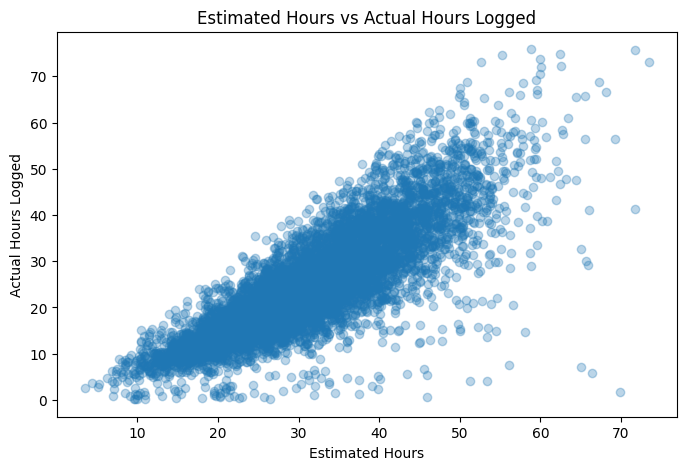

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["estimated_hours"],
    df["hours_logged"],
    alpha=0.3
)

plt.xlabel("Estimated Hours")
plt.ylabel("Actual Hours Logged")
plt.title("Estimated Hours vs Actual Hours Logged")

plt.show()

In [58]:
from xgboost import XGBRegressor

In [59]:
model_xgb = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

In [60]:
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("================================")
print("XGBOOST MODEL 3")
print("================================")

print(f"R² Score : {r2_xgb:.4f}")
print(f"MAE      : {mae_xgb:.2f} hours")

XGBOOST MODEL 3
R² Score : 0.6995
MAE      : 4.49 hours


In [61]:
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.to_string(index=False))

            Feature  Importance
    estimated_hours    0.654820
    task_complexity    0.124563
workload_percentage    0.059755
   allocation_score    0.045016
   experience_years    0.038832
  performance_score    0.038436
       active_tasks    0.018115
  task_priority_enc    0.015635
      duration_days    0.004829


In [62]:
df["estimation_error"] = (
    df["hours_logged"] - df["estimated_hours"]
)

print(df["estimation_error"].describe())

count    8016.000000
mean       -6.625574
std         6.355546
min       -68.120000
25%       -10.050000
50%        -6.600000
75%        -3.190000
max        20.560000
Name: estimation_error, dtype: float64


In [63]:
error_features = [
    "experience_years",
    "allocation_score",
    "workload_percentage",
    "performance_score",
    "active_tasks",
    "task_priority_enc",
    "duration_days",
    "progress_percentage"
]

error_corr = (
    df[error_features + ["estimation_error"]]
    .corr()["estimation_error"]
    .sort_values()
)

print(error_corr)

allocation_score      -0.190629
performance_score     -0.155129
duration_days         -0.113784
experience_years      -0.109375
progress_percentage   -0.022428
active_tasks           0.010517
task_priority_enc      0.201917
workload_percentage    0.223598
estimation_error       1.000000
Name: estimation_error, dtype: float64


In [73]:
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.to_string(index=False))

            Feature  Importance
    estimated_hours    0.742119
workload_percentage    0.066575
   allocation_score    0.047824
   experience_years    0.042103
  performance_score    0.041210
      duration_days    0.024303
       active_tasks    0.018759
  task_priority_enc    0.017107


In [74]:
import joblib

model_path = "task_completion_model.pkl"

joblib.dump(model, model_path)

print("Final Model 3 saved successfully!")
print("File:", model_path)

Final Model 3 saved successfully!
File: task_completion_model.pkl


In [76]:
import joblib

model_path = "../models/task_completion_model.pkl"

model = joblib.load(model_path)

print("Task Completion Time Model loaded successfully!")

Task Completion Time Model loaded successfully!


In [77]:
def predict_task_completion(task_info):
    
    loaded_model = joblib.load(
        model_path
    )

    input_data = pd.DataFrame([{
        "estimated_hours": task_info["estimated_hours"],
        "experience_years": task_info["experience_years"],
        "allocation_score": task_info["allocation_score"],
        "workload_percentage": task_info["workload_percentage"],
        "performance_score": task_info["performance_score"],
        "active_tasks": task_info["active_tasks"],
        "task_priority_enc": task_info["task_priority_enc"],
        "duration_days": task_info["duration_days"]
    }])

    predicted_hours = loaded_model.predict(
        input_data
    )[0]

    return round(float(predicted_hours), 2)

In [78]:
sample_task = {
    "estimated_hours": 10,
    "experience_years": 7,
    "allocation_score": 90,
    "workload_percentage": 36,
    "performance_score": 88,
    "active_tasks": 2,
    "task_priority_enc": 2,
    "duration_days": 20
}

prediction = predict_task_completion(sample_task)

print("Predicted completion time:", prediction, "hours")

Predicted completion time: 4.91 hours


In [83]:
def predict_and_allocate(task_info, employee_list):

    loaded_model = joblib.load(
        model_path
    )

    predictions = []

    for employee in employee_list:

        employee_features = pd.DataFrame([{
            "estimated_hours":
                task_info["estimated_hours"],

            "experience_years":
                employee["experience_years"],

            "allocation_score":
                employee["allocation_score"],

            "workload_percentage":
                employee["workload_percentage"],

            "performance_score":
                employee["performance_score"],

            "active_tasks":
                employee["active_tasks"],

            "task_priority_enc":
                task_info["task_priority_enc"],

            "duration_days":
                task_info["duration_days"]
        }])

        predicted_hours = loaded_model.predict(
            employee_features
        )[0]

        predictions.append({
            "employee_name":
                employee["employee_name"],

            "experience_years":
                employee["experience_years"],

            "workload_percentage":
                employee["workload_percentage"],

            "predicted_hours":
                float(predicted_hours)
        })

    # Average predicted time
    average_hours = np.mean([
        x["predicted_hours"]
        for x in predictions
    ])

    # Employee with minimum predicted time
    recommended = min(
        predictions,
        key=lambda x: x["predicted_hours"]
    )

    saving = (
        average_hours -
        recommended["predicted_hours"]
    )

    print("================================")
    print("BONUS AUTO-ALLOCATION")
    print("================================")

    print("\nPredictions:")

    for employee in predictions:
        print(
            f"{employee['employee_name']} → "
            f"{employee['predicted_hours']:.2f} hours"
        )

    print("\nRecommended Employee:")

    print(
        f"Recommended: "
        f"{recommended['employee_name']} "
        f"({recommended['experience_years']}yr, "
        f"{recommended['workload_percentage']:.0f}% workload) - "
        f"Predicted "
        f"{recommended['predicted_hours']:.1f} hrs "
        f"vs avg "
        f"{average_hours:.1f} hrs - "
        f"Saves "
        f"{saving:.1f} hrs"
    )

    return recommended

In [84]:
employee_list = [

    {
        "employee_name": "Anjali",
        "experience_years": 7,
        "allocation_score": 90,
        "workload_percentage": 36,
        "performance_score": 88,
        "active_tasks": 2
    },

    {
        "employee_name": "Rahul",
        "experience_years": 4,
        "allocation_score": 82,
        "workload_percentage": 48,
        "performance_score": 84,
        "active_tasks": 3
    },

    {
        "employee_name": "Meera",
        "experience_years": 9,
        "allocation_score": 87,
        "workload_percentage": 62,
        "performance_score": 91,
        "active_tasks": 4
    }

]

print("Employees created successfully!")

Employees created successfully!


In [85]:
task_info = {
    "estimated_hours": 10,
    "task_priority_enc": 2,
    "duration_days": 20
}

print(task_info)

{'estimated_hours': 10, 'task_priority_enc': 2, 'duration_days': 20}


In [86]:
recommended_employee = predict_and_allocate(
    task_info,
    employee_list
)

BONUS AUTO-ALLOCATION

Predictions:
Anjali → 4.91 hours
Rahul → 4.12 hours
Meera → 5.03 hours

Recommended Employee:
Recommended: Rahul (4yr, 48% workload) - Predicted 4.1 hrs vs avg 4.7 hrs - Saves 0.6 hrs
